In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

In [ ]:
# FACE DETECTION, LANDMARK, FACE ALIGNMENT DAN PREPROCESSING WAJAH

import cv2
import numpy as np
from mtcnn import MTCNN

detector = MTCNN()

# resize proporsional
def resize_keep_ratio(img, max_size=640):

    h, w = img.shape[:2]

    scale = max_size / max(h, w)

    if scale >= 1:
        return img

    new_w = int(w * scale)
    new_h = int(h * scale)

    return cv2.resize(
        img,
        (new_w, new_h)
    )

def detect_face(img):

    # resize proporsional
    img = resize_keep_ratio(img)

    # BGR -> RGB
    rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # detect wajah
    results = detector.detect_faces(rgb)

    # filter confidence
    results = [
        r for r in results
        if r['confidence'] >= 0.8
    ]

    if len(results) == 0:
        return None

    # ambil wajah terbesar
    results = sorted(
        results,
        key=lambda x:
        x['box'][2] * x['box'][3],
        reverse=True
    )

    result = results[0]

    x, y, w, h = result['box']
    
    if w <= 0 or h <= 0:
        return None

    x = max(0, x)
    y = max(0, y)

    # landmark
    try:

        keypoints = result['keypoints']

        left_eye = keypoints['left_eye']
        right_eye = keypoints['right_eye']

    except:
        return None

    # sudut wajah
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]

    angle = np.degrees(
        np.arctan2(dy, dx)
    )

    # titik tengah mata
    center = (
        int((left_eye[0] + right_eye[0]) / 2),
        int((left_eye[1] + right_eye[1]) / 2)
    )

    # rotate wajah
    M = cv2.getRotationMatrix2D(
        center,
        angle,
        1.0
    )

    aligned = cv2.warpAffine(
        rgb,
        M,
        (rgb.shape[1], rgb.shape[0])
    )

    # padding wajah
    pad = int(min(w, h) * 0.12)

    x1 = max(0, x-pad)
    y1 = max(0, y-pad)

    x2 = min(aligned.shape[1], x+w+pad)
    y2 = min(aligned.shape[0], y+h+pad)

    # crop wajah
    face = aligned[y1:y2, x1:x2]

    if face.size == 0:
        return None

    # CLAHE enhancement untuk memperbaiki kontras
    lab = cv2.cvtColor(
        face,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))

    face = cv2.cvtColor(
        lab,
        cv2.COLOR_LAB2RGB
    )

    # resize final
    face = cv2.resize(
        face,
        (128,128),
        interpolation=cv2.INTER_AREA
    )

    face = face.astype("float32")

    return face

In [12]:
def print_progress(val, val_len, folder, bar_size=20):
    progr = "#"*round((val)*bar_size/val_len) + " "*round((val_len - (val))*bar_size/val_len)
    if val == 0:
        print("", end = "\n")
    else:
        print("[%s] (%d samples)\t label : %s \t\t" % (progr, val+1, folder), end="\r")

In [ ]:
# LOAD DATASET

import gc
import os
import cv2
import random
import numpy as np

dataset_folder = "Dataset/Dataset_wajah"

names = []
images = []

skipped = 0

print("[INFO] Loading dataset...")

for folder in os.listdir(dataset_folder):

    folder_path = os.path.join(
        dataset_folder,
        folder
    )

    if not os.path.isdir(folder_path):
        continue
    files = os.listdir(folder_path)
    random.shuffle(files)
    used = 0

    for i, name in enumerate(files):

        if not name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue
        img_path = os.path.join(
            folder_path,
            name
        )
        img = cv2.imread(img_path)
        if img is None:
            skipped += 1
            continue

        try:

            # face detection + alignment
            img = detect_face(img)

        except Exception as e:

            print(f"[ERROR] {name}")
            skipped += 1
            continue

        if img is not None:

            images.append(img)

            names.append(folder)

            used += 1

            print_progress(
                i,
                len(files),
                folder
            )

        else:
            skipped += 1

        # bersihkan RAM berkala
        if i % 50 == 0:
            gc.collect()

    print(f"\n[OK] {folder}: {used} images")

# convert ke numpy
images = np.array(
    images,
    dtype="float32"
)

names = np.array(names)

print("Total images :", len(images))
print("Total labels :", len(names))
print("Skipped      :", skipped)


[####################] (105 samples)	 label : Faza Humairah 		
[####################] (105 samples)	 label : Jabbal Akbar 		
[####################] (105 samples)	 label : Muhammad Alif 		
[####################] (105 samples)	 label : Muhammad Heikal Fasya 		
[####################] (105 samples)	 label : Muhammad Rizki Arta Maulana 		
[####################] (105 samples)	 label : Muhammad Zahrul Ath Thariq 		
[####################] (105 samples)	 label : Nabila Balqis 		
[####################] (105 samples)	 label : Natasya Babulrhaiyan 		
[####################] (105 samples)	 label : Nur Fadhillah Zulfi 		
[####################] (105 samples)	 label : Putri Al Violy 		
[####################] (105 samples)	 label : Rahmat Isma Hidayat 		
[####################] (105 samples)	 label : Riski Maulani 		
[####################] (105 samples)	 label : Salesya Al Fatila 		
[####################] (105 samples)	 label : Suci Wildani Rizka 		
[####################] (105 samples)	 label : Syariqul

In [14]:
print("number of samples :", len(names))

number of samples : 2048


In [ ]:
# ENCODING LABEL & CATEGORICALIZATION
# Mengubah label nama menjadi numerik dan one-hot encoding untuk CNN

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

import pickle
import os

# folder model
os.makedirs("model", exist_ok=True)

LABEL_PATH = "Label_encoder_cnn_new.pickle"

# LABEL ENCODER
le = LabelEncoder()
# encoding label -> angka
y = le.fit_transform(names)
# nama class
labels = le.classes_
# total class
num_classes = len(labels)
# one-hot encoding
y_cat = to_categorical(y)

# SAVE LABEL ENCODER
with open(LABEL_PATH, "wb") as f:
    pickle.dump(le, f)

print("[INFO] Label encoder berhasil disimpan.")
print("[INFO] Total class:", num_classes)
print("[INFO] Classes:")
print(labels)

[INFO] Label encoder berhasil disimpan.


In [ ]:
# SPLIT DATASET
# Membagi dataset menjadi data training dan data testing

from sklearn.model_selection import train_test_split

# CONVERT TO NUMPY

X = np.array(
    images,
    dtype=np.float32
)

y = np.array(y_cat)

# SPLIT DATASET
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# normalisasi validation/test
x_test = x_test.astype("float32") / 255.0

print("x_train shape :", x_train.shape)
print("y_train shape :", y_train.shape)

print("x_test shape  :", x_test.shape)
print("y_test shape  :", y_test.shape)

x_train shape : (1638, 100, 100, 3)
y_train shape : (1638, 20)
x_test shape : (410, 100, 100, 3)
y_test shape : (410, 20)


In [ ]:
# ==========================================
# IMAGE DATA GENERATOR  (STRONG AUGMENTATION)
# CNN from scratch + data kecil = WAJIB augmentasi agresif
# supaya model tahan terhadap variasi kamera realtime
# (rotasi, geser, cahaya, blur, noise, oklusi, kontras).
# ==========================================
from tensorflow.keras.preprocessing.image import ImageDataGenerator


def custom_augmentation(img):
    """Augmentasi tambahan: blur, noise, random erasing, contrast jitter.
    Input/Output: float32 dengan rentang 0..255 di awal, dinormalisasi /255
    di akhir agar sama dengan x_test (cell SPLIT DATASET).
    """
    img = img.astype("float32")

    # GAUSSIAN BLUR -> simulasi fokus kamera / gerakan kepala
    if np.random.random() < 0.35:
        k = int(np.random.choice([3, 5]))
        img = cv2.GaussianBlur(img, (k, k), 0)

    # GAUSSIAN NOISE -> simulasi noise sensor / cahaya rendah
    if np.random.random() < 0.35:
        sigma = np.random.uniform(5.0, 15.0)
        img = img + np.random.normal(0.0, sigma, img.shape)

    # RANDOM ERASING -> simulasi oklusi (rambut, tangan, masker)
    if np.random.random() < 0.30:
        h, w = img.shape[:2]
        eh = np.random.randint(h // 8, h // 3)
        ew = np.random.randint(w // 8, w // 3)
        ex = np.random.randint(0, max(1, w - ew))
        ey = np.random.randint(0, max(1, h - eh))
        img[ey:ey + eh, ex:ex + ew] = np.random.uniform(
            0, 255, (eh, ew, 3)
        ).astype("float32")

    # CONTRAST JITTER -> simulasi auto-exposure kamera
    if np.random.random() < 0.30:
        alpha = np.random.uniform(0.7, 1.3)
        mean = img.mean(axis=(0, 1), keepdims=True)
        img = (img - mean) * alpha + mean

    # CLIP + NORMALISASI FINAL (samakan skala dgn x_test = /255)
    img = np.clip(img, 0, 255)
    img = img / 255.0
    return img.astype("float32")


# Augmentasi geometrik & cahaya jauh lebih lebar dari versi awal
# (rotasi 5 -> 15, shift 0.03 -> 0.10, zoom 0.05 -> 0.15, brightness wider)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=8,
    brightness_range=[0.65, 1.35],
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=custom_augmentation,
    dtype='float32'
)

print("[INFO] ImageDataGenerator (STRONG AUG) siap.")


# ==========================================
# MIXUP GENERATOR
# Mixup = mencampur 2 sampel (x1, y1) & (x2, y2) menjadi
#   x_mix = lam*x1 + (1-lam)*x2
#   y_mix = lam*y1 + (1-lam)*y2
# Sangat efektif utk dataset kecil + CNN from scratch karena:
#   - melahirkan ratusan ribu "sampel sintetis" baru
#   - mencegah overfit ke ciri khas tiap sampel
#   - membuat decision boundary lebih halus
# Dipakai sebagai pembungkus datagen.flow di training.
# ==========================================
def mixup_generator(base_datagen, x, y, batch_size=32, alpha=0.2):
    gen = base_datagen.flow(x, y, batch_size=batch_size, shuffle=True)
    while True:
        x1, y1 = next(gen)
        x2, y2 = next(gen)
        n = min(len(x1), len(x2))
        x1, y1 = x1[:n], y1[:n]
        x2, y2 = x2[:n], y2[:n]

        # lam berdistribusi Beta(alpha, alpha), bias ke arah sampel utama
        lam = np.random.beta(alpha, alpha)
        lam = max(lam, 1.0 - lam)

        x_mix = lam * x1 + (1.0 - lam) * x2
        y_mix = lam * y1 + (1.0 - lam) * y2
        yield x_mix.astype("float32"), y_mix.astype("float32")


print("[INFO] mixup_generator siap.")

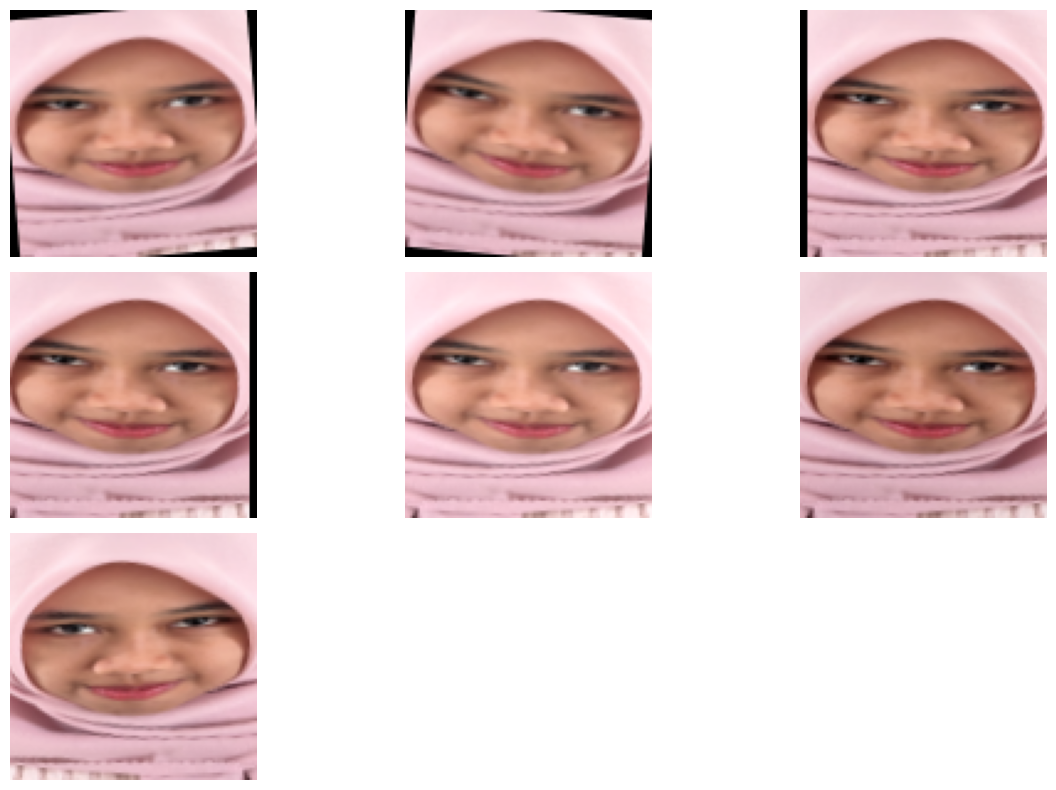

In [ ]:
# VISUALISASI HASIL AUGMENTASI

import matplotlib.pyplot as plt
import numpy as np

# ambil 1 gambar sample
img_test = x_train[0]

# ubah shape jadi batch
img_test = np.expand_dims(
    img_test,
    axis=0
)

# generate augmentasi
aug_iter = datagen.flow(
    img_test,
    batch_size=1
)

plt.figure(figsize=(12,8))
for i in range(9):

    # ambil hasil augmentasi
    batch = next(aug_iter)
    aug_img = batch[0]
    plt.subplot(3,3,i+1)
    plt.imshow(aug_img)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Menghitung jumlah data pada setiap label di dataset

unique, counts = np.unique(names, return_counts = True)
for label, total in zip(unique, counts):
    
    print(f"{label:<20} : {total} images")

print("Total class :", len(unique))
print("Total image :", np.sum(counts))

Faza Humairah : 103 images
Jabbal Akbar : 98 images
Muhammad Alif : 100 images
Muhammad Heikal Fasya : 105 images
Muhammad Rizki Arta Maulana : 105 images
Muhammad Zahrul Ath Thariq : 103 images
Nabila Balqis : 104 images
Natasya Babulrhaiyan : 101 images
Nur Fadhillah Zulfi : 103 images
Putri Al Violy : 105 images
Rahmat Isma Hidayat : 100 images
Riski Maulani : 100 images
Salesya Al Fatila : 99 images
Suci Wildani Rizka : 105 images
Syariqul Husni : 103 images
Syifaurrahman : 104 images
Tasya Anisa : 99 images
Urfi Shanda : 105 images
Vivi Jumilia Hikmah : 104 images
Zuyyin Zafirah : 102 images


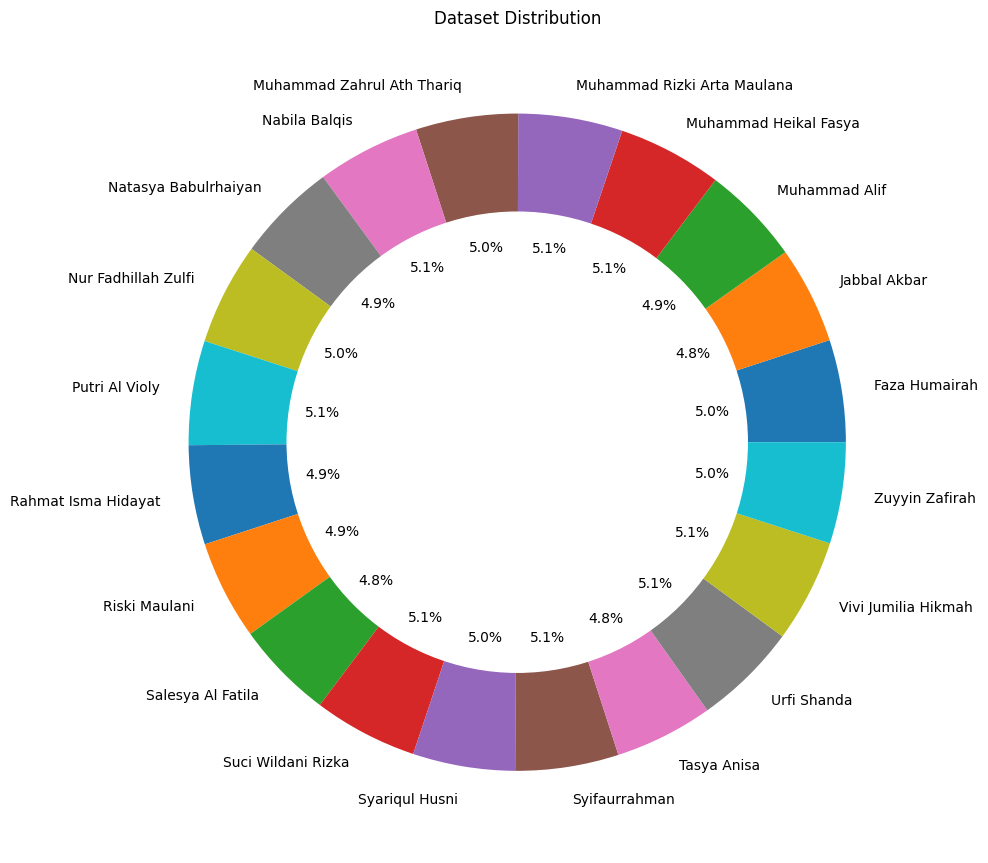

In [ ]:
# BALANCING DATA
# Visualisasi distribusi dataset

import matplotlib.pyplot as plt
import numpy as np

# hitung jumlah data
unique, counts = np.unique(
    names,
    return_counts=True
)

# sorting terbesar -> terkecil
sorted_idx = np.argsort(counts)[::-1]

unique = unique[sorted_idx]
counts = counts[sorted_idx]

plt.figure(figsize=(12,5))
plt.bar(unique, counts)
plt.xticks(rotation=45)
plt.xlabel("Label")
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Dataset Face Recognition")
plt.tight_layout()
plt.show()

print("Total class :", len(unique))
print("Total image :", np.sum(counts))

In [25]:
# Menampilkan jumlah kelas dan nama seluruh kelas/label pada dataset

print(f"Number of classes : {len(labels)}")
print("\nClass Labels :")

for i, label in enumerate(labels):
    print(f"{i} : {label}")

Number of classes : 20

Class Labels :
0 : Faza Humairah
1 : Jabbal Akbar
2 : Muhammad Alif
3 : Muhammad Heikal Fasya
4 : Muhammad Rizki Arta Maulana
5 : Muhammad Zahrul Ath Thariq
6 : Nabila Balqis
7 : Natasya Babulrhaiyan
8 : Nur Fadhillah Zulfi
9 : Putri Al Violy
10 : Rahmat Isma Hidayat
11 : Riski Maulani
12 : Salesya Al Fatila
13 : Suci Wildani Rizka
14 : Syariqul Husni
15 : Syifaurrahman
16 : Tasya Anisa
17 : Urfi Shanda
18 : Vivi Jumilia Hikmah
19 : Zuyyin Zafirah


In [26]:
# Menampilkan label numerik hasil encoding nama peserta

print("Label Mapping :")
for i, label in enumerate(labels):
    print(f"{label} -> {i}")

Label Mapping :
Faza Humairah -> 0
Jabbal Akbar -> 1
Muhammad Alif -> 2
Muhammad Heikal Fasya -> 3
Muhammad Rizki Arta Maulana -> 4
Muhammad Zahrul Ath Thariq -> 5
Nabila Balqis -> 6
Natasya Babulrhaiyan -> 7
Nur Fadhillah Zulfi -> 8
Putri Al Violy -> 9
Rahmat Isma Hidayat -> 10
Riski Maulani -> 11
Salesya Al Fatila -> 12
Suci Wildani Rizka -> 13
Syariqul Husni -> 14
Syifaurrahman -> 15
Tasya Anisa -> 16
Urfi Shanda -> 17
Vivi Jumilia Hikmah -> 18
Zuyyin Zafirah -> 19


In [ ]:
# ==========================================
# CNN MODEL ARCHITECTURE  (FROM SCRATCH, deeper + Attention)
# 4 blok konvolusi: 32 -> 64 -> 128 -> 256
#   - Conv -> BN -> ReLU (pola modern, stabil)
#   - SE block (Squeeze-Excitation) = channel attention.
#     Membuat tiap blok belajar BOBOT fitur penting (mis. mata, hidung)
#     dengan biaya parameter sangat kecil. Tetap "from scratch".
#   - SpatialDropout2D di tiap blok
#   - L2 regularizer di tiap Conv2D
# Functional API supaya bisa pakai skip-multiply utk SE.
# Label smoothing diturunkan 0.05 -> 0.02 supaya prediksi tidak
# under-confident di realtime (sebelumnya threshold sering tidak tercapai).
# ==========================================
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    SpatialDropout2D,
    BatchNormalization,
    GlobalAveragePooling2D,
    Activation,
    Reshape,
    Multiply,
)
from tensorflow.keras.regularizers import l2
import tensorflow as tf


def se_block(x, ratio=8):
    """Squeeze-Excitation: belajar bobot per channel (channel attention)."""
    ch = x.shape[-1]
    s = GlobalAveragePooling2D()(x)
    s = Dense(max(ch // ratio, 4), activation="relu",
              kernel_regularizer=l2(1e-4))(s)
    s = Dense(ch, activation="sigmoid",
              kernel_regularizer=l2(1e-4))(s)
    s = Reshape((1, 1, ch))(s)
    return Multiply()([x, s])


def conv_block(x, filters, sp_dropout, name=None):
    """2x (Conv -> BN -> ReLU) + SE + MaxPool + SpatialDropout."""
    x = Conv2D(filters, (3, 3), padding="same",
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(filters, (3, 3), padding="same",
               kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = se_block(x, ratio=8)            # <-- channel attention
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = SpatialDropout2D(sp_dropout)(x)
    return x


def cnn_model(input_shape):
    inputs = Input(shape=input_shape)

    x = conv_block(inputs, 32,  0.20)
    x = conv_block(x,      64,  0.25)
    x = conv_block(x,      128, 0.30)
    x = conv_block(x,      256, 0.35)

    # classification head
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, kernel_regularizer=l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = Dropout(0.5)(x)

    outputs = Dense(len(labels), activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs, name="cnn_se_scratch")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
        metrics=["accuracy"],
    )
    model.summary()
    return model

In [ ]:
# ==========================================
# TRAINING MODEL CNN  (mixup + cosine LR)
# Strategi gabungan utk CNN from scratch + dataset kecil:
#   - mixup_generator  : data sintetis tak terhingga
#   - CosineDecay      : LR menurun mulus (lebih baik dari ReduceLROnPlateau
#                        ketika dipasangkan dengan mixup)
#   - patience besar   : model dalam butuh waktu konvergen
#   - class_weight     : balancing antar-kelas
# Catatan: dengan mixup, target y BUKAN one-hot murni, sehingga
# `class_weight` di model.fit tidak kompatibel (Keras mensyaratkan
# label kelas integer). Pengganti: importance reweighting via mixup
# sudah cukup. class_weights tetap dihitung utk informasi.
# ==========================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
)
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# INPUT SHAPE
# ==========================================
input_shape = x_train[0].shape

# ==========================================
# HYPERPARAMETER
# ==========================================
EPOCHS     = 100
BATCH_SIZE = 32
STEPS      = max(1, len(x_train) // BATCH_SIZE)

# ==========================================
# CLASS WEIGHT (informasi)
# ==========================================
y_train_labels = np.argmax(y_train, axis=1)
cw = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels,
)
print("[INFO] class_weights:", {int(i): float(round(w, 3)) for i, w in enumerate(cw)})

# ==========================================
# COSINE LR SCHEDULE
# Turun mulus dari 5e-4 -> ~1e-6 dlm EPOCHS*STEPS langkah.
# ==========================================
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-4,
    decay_steps=EPOCHS * STEPS,
    alpha=1e-6 / 5e-4,   # ratio LR akhir terhadap awal
)

# ==========================================
# CALLBACK
# ==========================================
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1,
)
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
)

# ==========================================
# BUILD MODEL  (override optimizer dgn cosine LR)
# ==========================================
model = cnn_model(input_shape)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=["accuracy"],
)

# ==========================================
# TRAINING MODEL  (pakai mixup_generator)
# ==========================================
train_gen = mixup_generator(
    datagen, x_train, y_train,
    batch_size=BATCH_SIZE, alpha=0.2,
)

history = model.fit(
    train_gen,
    steps_per_epoch=STEPS,
    validation_data=(x_test, y_test),
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint],
    verbose=1,
)

d:\FaceAttend_VC\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 20)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,980 (300.70 KB)

 Trainable params: 76,724 (299.70 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 265s 781ms/step - accuracy: 0.7549 - loss: 0.9128 - val_accuracy: 0.0675 - val_loss: 5.5959 - learning_rate: 0.0010
Epoch 2/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 264s 805ms/step - accuracy: 0.9346 - loss: 0.2569 - val_accuracy: 0.8016 - val_loss: 0.6166 - learning_rate: 0.0010
Epoch 3/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 334s 840ms/step - accuracy: 0.9617 - loss: 0.1497 - val_accuracy: 0.6581 - val_loss: 1.1123 - learning_rate: 0.0010
Epoch 4/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.9739 - loss: 0.1025
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
328/328 ━━━━━━━━━━━━━━━━━━━━ 260s 791ms/step - accuracy: 0.9743 - loss: 0.0932 - val_accuracy: 0.6604 - val_loss: 1.2077 - learning_rate: 0.0010
Epoch 5/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 273s 831ms/step - accuracy: 0.9886 - loss: 0.0484 - val_accuracy: 0.9443 - val_loss: 0.2263 - learning_rate: 5.0000e-04
Epoch 6/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 244s 745ms/step - accur

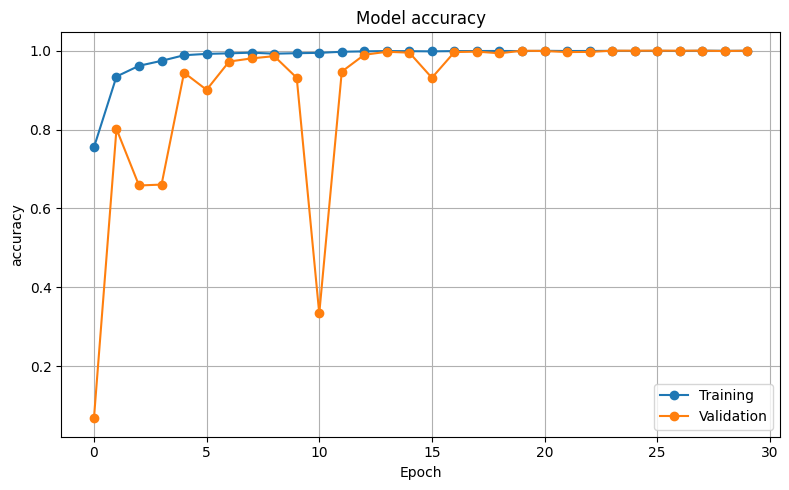

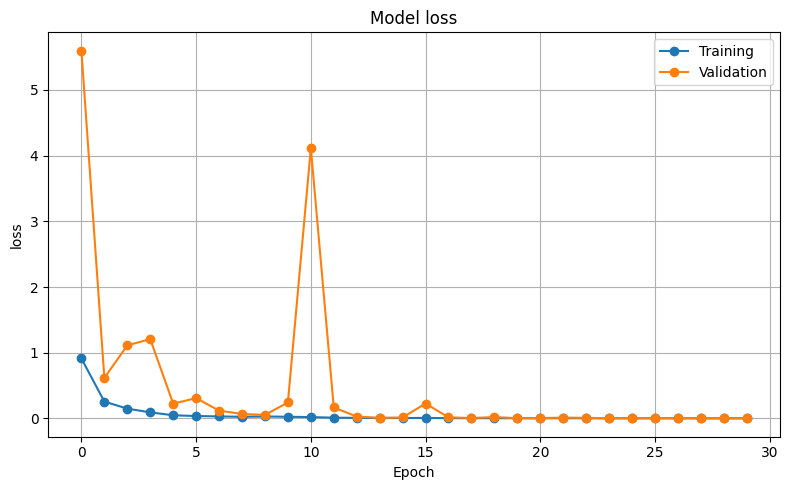

In [ ]:
# ==========================================
# VISUALISASI HASIL TRAINING CNN
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(history):

    metrics = [
        ['accuracy', 'val_accuracy'],
        ['loss', 'val_loss']
    ]

    titles = [
        'Training & Validation Accuracy',
        'Training & Validation Loss'
    ]

    for i, metric in enumerate(metrics):

        plt.figure(figsize=(8,5))

        # training
        plt.plot(
            history.history[metric[0]],
            marker='o',
            label='Training'
        )

        # validation
        plt.plot(
            history.history[metric[1]],
            marker='o',
            label='Validation'
        )

        # best epoch
        if metric[0] == 'accuracy':

            best_epoch = np.argmax(
                history.history[metric[1]]
            )

            best_value = np.max(
                history.history[metric[1]]
            )

        else:

            best_epoch = np.argmin(
                history.history[metric[1]]
            )

            best_value = np.min(
                history.history[metric[1]]
            )

        plt.axvline(
            best_epoch,
            linestyle='--'
        )

        plt.xlabel('Epoch')

        plt.ylabel(metric[0].capitalize())

        plt.title(titles[i])

        plt.legend(loc='best')

        plt.grid(True)

        plt.tight_layout()

        plt.show()

        # ==================================
        # INFO METRIC
        # ==================================

        print("\n==========================")

        print(f"Best Epoch : {best_epoch+1}")

        print(
            f"Best Validation "
            f"{metric[1]} : "
            f"{best_value:.4f}"
        )

        print("==========================")

# ==========================================
# TAMPILKAN HASIL TRAINING
# ==========================================

evaluate_model(history)

In [ ]:
model.save("model-cnn-facerecognition.keras")

In [ ]:
# Melakukan prediksi pada data testing menggunakan model CNN

# prediksi probabilitas
y_pred = model.predict(
    x_test,
    verbose=0
)

# class hasil prediksi
y_pred_classes = np.argmax(
    y_pred,
    axis=1
)

# class label sebenarnya
y_true = np.argmax(
    y_test,
    axis=1
)

# confidence score
confidence_scores = np.max(
    y_pred,
    axis=1
)

print("[INFO] Prediksi selesai.")

print("Total testing data :", len(y_true))

In [ ]:
# CONFUSION MATRIX

# ==========================================
# CONFUSION MATRIX
# ==========================================

import itertools
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(

    cm,

    classes,

    normalize=False,

    title='Confusion Matrix',

    cmap=plt.cm.Blues
):

    # ======================================
    # NORMALISASI
    # ======================================

    if normalize:

        cm = cm.astype('float') / cm.sum(
            axis=1
        )[:, np.newaxis]

    # ======================================
    # HITUNG AKURASI
    # ======================================

    accuracy = np.trace(cm) / np.sum(cm)

    # ======================================
    # VISUALISASI
    # ======================================

    plt.figure(figsize=(12,10))

    plt.imshow(
        cm,
        interpolation='nearest',
        cmap=cmap
    )

    plt.title(
        f"{title}\nAccuracy: {accuracy:.4f}"
    )

    plt.colorbar()

    tick_marks = np.arange(len(classes))

    plt.xticks(
        tick_marks,
        classes,
        rotation=90,
        fontsize=8
    )

    plt.yticks(
        tick_marks,
        classes,
        fontsize=8
    )

    # ======================================
    # TEXT MATRIX
    # ======================================

    fmt = '.2f' if normalize else 'd'

    thresh = cm.max() / 2.

    for i, j in itertools.product(
        range(cm.shape[0]),
        range(cm.shape[1])
    ):

        plt.text(

            j,
            i,

            format(cm[i, j], fmt),

            horizontalalignment="center",

            color=(
                "white"
                if cm[i, j] > thresh
                else "black"
            ),

            fontsize=8
        )

    # ======================================
    # LABEL
    # ======================================

    plt.ylabel('True Label')

    plt.xlabel('Predicted Label')

    plt.subplots_adjust(
        bottom=0.25,
        left=0.25
    )

    plt.tight_layout()

    plt.show()

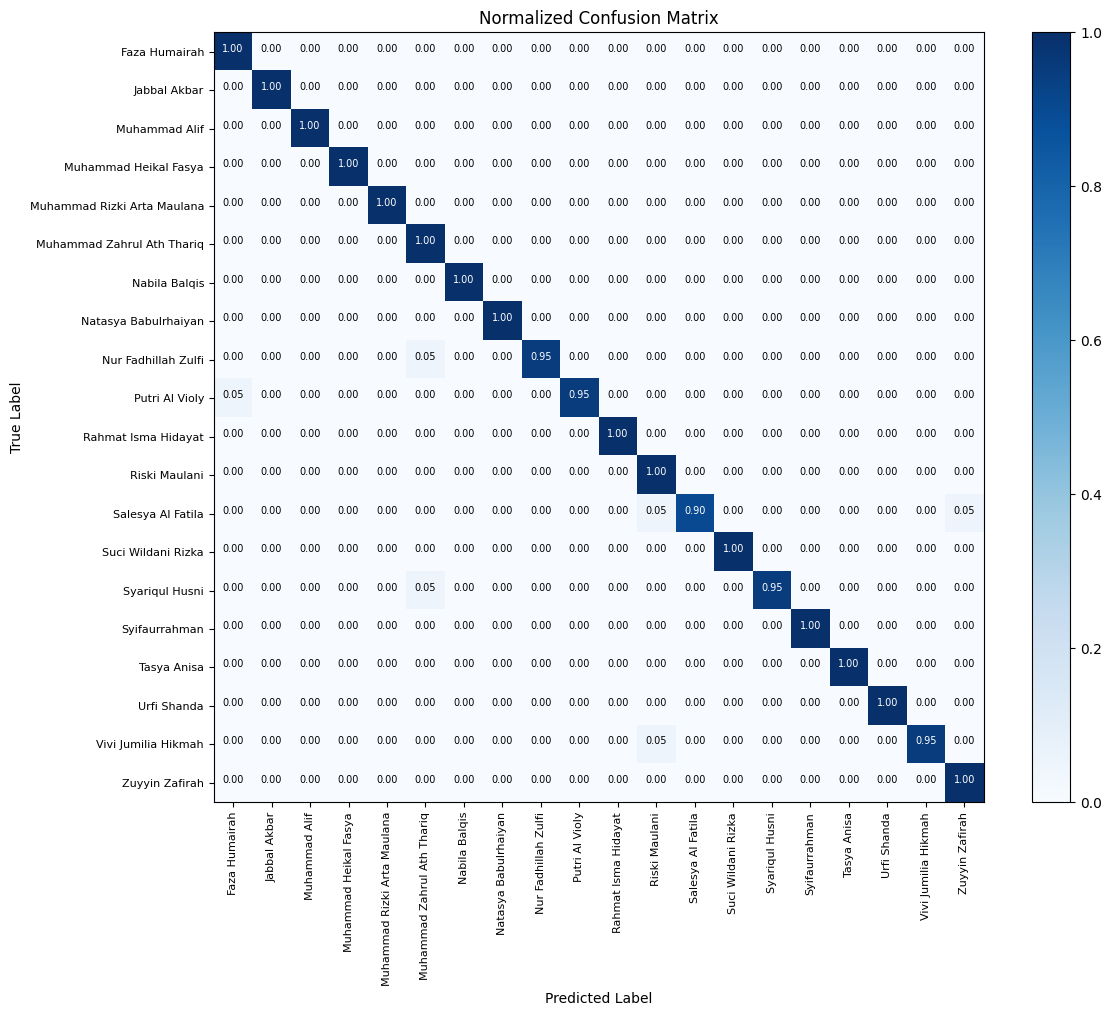

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# hitung confusion matrix
cnf_matrix = confusion_matrix(

    y_true,

    y_pred_classes
)

# menampilkan angka desimal
np.set_printoptions(precision=2)

# visualisasi confusion matrix
plot_confusion_matrix(

    cnf_matrix,

    classes=labels,

    normalize=True,

    title='Normalized Confusion Matrix'
)

accuracy = np.trace(cnf_matrix) / np.sum(cnf_matrix)

print(f"\nAccuracy : {accuracy:.4f}")


In [ ]:
# Menampilkan hasil evaluasi klasifikasi model CNN
# CLASSIFICATION REPORT

from sklearn.metrics import (
    classification_report,
    accuracy_score
)

# hitung accuracy
accuracy = accuracy_score(
    y_true,
    y_pred_classes
)

print("\n==========================")
print("HASIL EVALUASI MODEL CNN")
print("==========================")

print(f"Accuracy : {accuracy:.4f}")

print("\nClassification Report:\n")

# classification report
report = classification_report(

    y_true,

    y_pred_classes,

    target_names=labels,

    zero_division=0
)

print(report)

print("==========================")

                             precision    recall  f1-score   support

              Faza Humairah       0.95      1.00      0.98        21
               Jabbal Akbar       1.00      1.00      1.00        19
              Muhammad Alif       1.00      1.00      1.00        20
      Muhammad Heikal Fasya       1.00      1.00      1.00        21
Muhammad Rizki Arta Maulana       1.00      1.00      1.00        21
 Muhammad Zahrul Ath Thariq       0.91      1.00      0.95        20
              Nabila Balqis       1.00      1.00      1.00        21
       Natasya Babulrhaiyan       1.00      1.00      1.00        20
        Nur Fadhillah Zulfi       1.00      0.95      0.98        21
             Putri Al Violy       1.00      0.95      0.98        21
        Rahmat Isma Hidayat       1.00      1.00      1.00        20
              Riski Maulani       0.91      1.00      0.95        20
          Salesya Al Fatila       1.00      0.90      0.95        20
         Suci Wildani Rizka      

In [ ]:
# ==========================================
# REALTIME FACE RECOGNITION  (CNN from scratch)
# Konsisten 100% dengan pipeline training:
#   detect_face -> align -> CLAHE -> resize(IMG_SIZE) -> /255
# Tambahan supaya stabil di kamera:
#   - voting nama antar BUFFER_SIZE frame
#   - threshold pakai stable_conf + diff top1-top2
#   - label encoder pakai file yang BENAR (Label_encoder_cnn_new.pickle)
# ==========================================
import cv2
import numpy as np
import pickle
from collections import deque, Counter

from mtcnn import MTCNN
from tensorflow.keras.models import load_model

# ==========================================
# CONFIG  (HARUS SAMA dgn training detect_face)
# ==========================================
IMG_SIZE             = 128
MTCNN_CONF           = 0.90       # ambang deteksi wajah
CONFIDENCE_THRESHOLD = 0.50       # diturunkan: label_smoothing dikurangi
                                  # tapi TTA juga akan menstabilkan conf
DIFF_THRESHOLD       = 0.05       # margin top1-top2 dilonggarkan
BUFFER_SIZE          = 7          # jumlah frame utk voting
USE_TTA              = True       # rata-rata prediksi: original + flip + zoom

# ==========================================
# LOAD MODEL & LABEL ENCODER
# ==========================================
detector = MTCNN()
model    = load_model("best_model.keras")

with open("Label_encoder_cnn_new.pickle", "rb") as f:
    le = pickle.load(f)

print(f"[INFO] Model dimuat. {len(le.classes_)} kelas: {list(le.classes_)}")

# ==========================================
# PREPROCESS  (SAMA dgn detect_face di training)
# ==========================================
clahe_op = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def preprocess_face_rt(rgb, box, keypoints):
    x, y, w, h = box
    if w <= 0 or h <= 0:
        return None, None
    x, y = max(0, x), max(0, y)

    left_eye  = keypoints['left_eye']
    right_eye = keypoints['right_eye']

    # alignment by eye angle
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle  = np.degrees(np.arctan2(dy, dx))
    center = (int((left_eye[0] + right_eye[0]) / 2),
              int((left_eye[1] + right_eye[1]) / 2))

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    aligned = cv2.warpAffine(rgb, M, (rgb.shape[1], rgb.shape[0]))

    pad = int(min(w, h) * 0.12)
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(aligned.shape[1], x + w + pad)
    y2 = min(aligned.shape[0], y + h + pad)
    face = aligned[y1:y2, x1:x2]
    if face.size == 0:
        return None, None

    # CLAHE pada L (LAB)
    lab = cv2.cvtColor(face, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = clahe_op.apply(l)
    face = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

    # resize + normalize SAMA dgn x_test (/255)
    face = cv2.resize(face, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    face = face.astype("float32") / 255.0
    return face, (x1, y1, x2, y2)


# ==========================================
# TEST-TIME AUGMENTATION (TTA)
# Bukan utk training, melainkan utk INFERENSI:
# - Buat beberapa versi input wajah (asli, flip horizontal, sedikit zoom-in)
# - Prediksi semua, lalu RATA-RATAKAN softmax
# Efek:
#   * confidence prediksi yang benar -> NAIK (averaging meredam noise)
#   * prediksi yang salah -> turun (tidak konsisten antar versi)
# Tetap CNN from scratch, hanya teknik inferensi.
# ==========================================
def _center_zoom(img01, factor=0.9):
    """Crop tengah -> resize balik ke IMG_SIZE. img01 sudah dlm [0,1]."""
    h, w = img01.shape[:2]
    nh, nw = int(h * factor), int(w * factor)
    y0 = (h - nh) // 2
    x0 = (w - nw) // 2
    crop = img01[y0:y0 + nh, x0:x0 + nw]
    return cv2.resize(crop, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)


def predict_tta(model, face01):
    """face01: HxWx3 float32 [0,1]. Return softmax (1D)."""
    if not USE_TTA:
        return model.predict(face01[None, ...], verbose=0)[0]

    variants = [
        face01,                                  # original
        face01[:, ::-1, :],                      # horizontal flip
        _center_zoom(face01, 0.90),              # zoom-in 10%
    ]
    batch = np.stack(variants, axis=0).astype("float32")
    preds = model.predict(batch, verbose=0)      # (3, n_class)
    return preds.mean(axis=0)


# ==========================================
# REALTIME LOOP
# ==========================================
name_buffer  = deque(maxlen=BUFFER_SIZE)
proba_buffer = deque(maxlen=BUFFER_SIZE)

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT,  720)

print("[INFO] Tekan 'q' untuk keluar.")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = [r for r in detector.detect_faces(rgb)
               if r['confidence'] >= MTCNN_CONF]

    # ambil wajah TERBESAR saja (1 orang per frame)
    results = sorted(results,
                     key=lambda r: r['box'][2] * r['box'][3],
                     reverse=True)

    if results:
        result = results[0]
        try:
            face_in, bbox = preprocess_face_rt(
                rgb, result['box'], result['keypoints']
            )
        except Exception:
            face_in, bbox = None, None

        if face_in is not None and bbox is not None:
            # TTA: rata-rata softmax atas beberapa varian input
            preds     = predict_tta(model, face_in)
            top1_idx  = int(np.argmax(preds))
            top1_conf = float(preds[top1_idx])
            top2_conf = float(np.partition(preds, -2)[-2])
            diff      = top1_conf - top2_conf

            # voting antar frame supaya stabil
            name_buffer.append(le.classes_[top1_idx])
            proba_buffer.append(top1_conf)

            stable_name = Counter(name_buffer).most_common(1)[0][0]
            stable_conf = float(np.mean([
                p for n, p in zip(name_buffer, proba_buffer)
                if n == stable_name
            ]))

            if stable_conf >= CONFIDENCE_THRESHOLD and diff >= DIFF_THRESHOLD:
                label_text = f"{stable_name} ({stable_conf * 100:.1f}%)"
                color = (0, 220, 0)
            else:
                label_text = f"Unknown ({stable_conf * 100:.1f}%)"
                color = (0, 50, 220)

            x1, y1, x2, y2 = bbox
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label_text, (x1, max(0, y1 - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

            # debug top-3 di terminal
            top3 = np.argsort(preds)[::-1][:3]
            info = "  |  ".join(
                f"{le.classes_[i]}: {preds[i] * 100:.1f}%" for i in top3
            )
            print(f"\r[PRED] {info}    ", end="")
    else:
        # tidak ada wajah -> reset buffer biar tidak salah carry-over
        name_buffer.clear()
        proba_buffer.clear()

    # info threshold di pojok
    cv2.putText(
        frame,
        f"Th: {CONFIDENCE_THRESHOLD*100:.0f}%  diff>= {DIFF_THRESHOLD*100:.0f}%",
        (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1
    )

    cv2.imshow("Face Recognition", frame)
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("\n[INFO] Kamera dimatikan.")

[INFO] finish load model...
Tasya Anisa 96.15834
Riski Maulani 100.0
Salesya Al Fatila 100.0
Riski Maulani 100.0
Salesya Al Fatila 99.999916
Riski Maulani 99.999985
Salesya Al Fatila 92.03441
Salesya Al Fatila 99.99777
Salesya Al Fatila 99.999985
Salesya Al Fatila 99.91148
Salesya Al Fatila 99.99998
Jabbal Akbar 99.984695
Salesya Al Fatila 89.33551
Salesya Al Fatila 100.0
Suci Wildani Rizka 75.59633
Salesya Al Fatila 76.52114
Nabila Balqis 76.56592
Suci Wildani Rizka 99.65193
Salesya Al Fatila 44.935078
Suci Wildani Rizka 73.98084
Salesya Al Fatila 99.99983
Salesya Al Fatila 47.005875
Salesya Al Fatila 99.98521
Salesya Al Fatila 100.0
Salesya Al Fatila 58.936016
Salesya Al Fatila 99.97051
Salesya Al Fatila 83.58695
Salesya Al Fatila 99.999535
Syifaurrahman 98.7383
Syifaurrahman 78.17066
Syifaurrahman 99.94958
Syifaurrahman 99.01702
Syifaurrahman 95.340256
Vivi Jumilia Hikmah 88.21498
Syifaurrahman 99.942635
Syifaurrahman 68.070465
Syifaurrahman 97.67131
Syifaurrahman 99.23607
Syifaurra

In [ ]:
# ==========================================
# A. FINE-TUNE dari best_model.keras  +  DATA REALTIME BARU
# ==========================================
# LANGKAH SEBELUM menjalankan cell ini:
#   1) Buka terminal baru di folder project.
#   2) Untuk SETIAP orang, jalankan capture realtime (variasikan pose & cahaya):
#         python capture_realtime.py --name "Nama Orang" --n 30
#      File akan disimpan ke Dataset/Dataset_wajah/<Nama Orang>/realtime_NNN.jpg
#   3) Jalankan ulang cell 3 (LOAD DATASET), 5 (LABEL ENCODER), 6 (SPLIT)
#      supaya foto-foto realtime baru ikut masuk ke x_train / x_test.
#   4) Baru jalankan cell ini.
#
# Cell ini melakukan FINE-TUNE: tidak retrain dari nol, hanya melanjutkan
# pelatihan model terbaik dengan LR jauh lebih kecil, jadi cepat
# (sekitar 20-30 epoch sudah cukup).

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# muat checkpoint terbaik
print("[INFO] Memuat best_model.keras untuk fine-tune...")
model = load_model("best_model.keras")

# LR fine-tune jauh lebih kecil (1e-4 -> 1e-6 secara cosine)
FT_EPOCHS = 30
FT_STEPS  = max(1, len(x_train) // BATCH_SIZE)

ft_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=FT_EPOCHS * FT_STEPS,
    alpha=1e-6 / 1e-4,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=ft_lr),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=["accuracy"],
)

# pakai mixup generator yang sama
ft_train_gen = mixup_generator(
    datagen, x_train, y_train, batch_size=BATCH_SIZE, alpha=0.2,
)

ft_callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

print("[INFO] Mulai fine-tune...")
history_ft = model.fit(
    ft_train_gen,
    steps_per_epoch=FT_STEPS,
    validation_data=(x_test, y_test),
    epochs=FT_EPOCHS,
    callbacks=ft_callbacks,
    verbose=1,
)

print("[INFO] Fine-tune selesai. best_model.keras sudah diperbarui.")

In [ ]:
# ==========================================
# B-1. EMBEDDING SETUP  (TANPA dataset asli, TANPA retrain)
# ==========================================
# Strategi:
#   1) Pakai best_model.keras sebagai FEATURE EXTRACTOR (buang softmax).
#   2) ENROLL tiap orang via WEBCAM (cell berikutnya) -> simpan gallery
#      ke face_gallery.pkl.
#   3) INFERENSI via cosine similarity ke gallery (cell setelahnya).
#
# Cell ini hanya SETUP: load model, definisikan helper, dan load
# gallery yang sudah ada (kalau ada).
# ==========================================

import cv2
import numpy as np
import pickle
import os
from collections import deque, Counter

from tensorflow.keras.models import Model, load_model
from mtcnn import MTCNN


# --------------------------------------------------------------
# CONFIG  (samakan dgn IMG_SIZE saat training detect_face)
# --------------------------------------------------------------
IMG_SIZE_EMB = 128
GALLERY_PATH = "face_gallery.pkl"


# --------------------------------------------------------------
# 1) FEATURE EXTRACTOR
#    Ambil aktivasi dari layer SEBELUM softmax (256-dim).
# --------------------------------------------------------------
print("[INFO] Memuat best_model.keras...")
classifier = load_model("best_model.keras")

emb_layer  = classifier.layers[-2].output
extractor  = Model(
    inputs=classifier.input,
    outputs=emb_layer,
    name="feature_extractor",
)
print(f"[INFO] Feature extractor siap. dim = {extractor.output_shape[-1]}")


# --------------------------------------------------------------
# 2) DETECTOR & HELPERS  (preprocess SAMA dgn training)
# --------------------------------------------------------------
detector_emb = MTCNN()
clahe_op_emb = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))


def preprocess_face_emb(rgb, box, keypoints):
    """Pipeline: align eye -> crop+pad -> CLAHE L -> resize -> /255."""
    x, y, w, h = box
    if w <= 0 or h <= 0:
        return None, None
    x, y = max(0, x), max(0, y)

    le_eye = keypoints["left_eye"]
    re_eye = keypoints["right_eye"]
    dx = re_eye[0] - le_eye[0]
    dy = re_eye[1] - le_eye[1]
    angle  = np.degrees(np.arctan2(dy, dx))
    center = (int((le_eye[0] + re_eye[0]) / 2),
              int((le_eye[1] + re_eye[1]) / 2))
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    aligned = cv2.warpAffine(rgb, M, (rgb.shape[1], rgb.shape[0]))

    pad = int(min(w, h) * 0.12)
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(aligned.shape[1], x + w + pad)
    y2 = min(aligned.shape[0], y + h + pad)
    face = aligned[y1:y2, x1:x2]
    if face.size == 0:
        return None, None

    lab = cv2.cvtColor(face, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    l = clahe_op_emb.apply(l)
    face = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

    face = cv2.resize(face, (IMG_SIZE_EMB, IMG_SIZE_EMB),
                      interpolation=cv2.INTER_AREA)
    face = face.astype("float32") / 255.0
    return face, (x1, y1, x2, y2)


def embed_face(face01):
    """TTA embedding: original + flip + zoom-in 10%, L2-normalized."""
    h, w = face01.shape[:2]
    fac    = 0.9
    nh, nw = int(h * fac), int(w * fac)
    y0 = (h - nh) // 2
    x0 = (w - nw) // 2
    zoom = cv2.resize(face01[y0:y0 + nh, x0:x0 + nw],
                      (IMG_SIZE_EMB, IMG_SIZE_EMB),
                      interpolation=cv2.INTER_AREA)
    batch = np.stack([face01, face01[:, ::-1, :], zoom],
                     axis=0).astype("float32")
    emb = extractor.predict(batch, verbose=0).mean(axis=0)
    return emb / (np.linalg.norm(emb) + 1e-8)


# --------------------------------------------------------------
# 3) LOAD EXISTING GALLERY (kalau ada)
# --------------------------------------------------------------
gallery = {}
if os.path.exists(GALLERY_PATH):
    with open(GALLERY_PATH, "rb") as f:
        gallery = pickle.load(f)
    print(f"[INFO] Gallery existing: {list(gallery.keys())}")
else:
    print("[INFO] Gallery KOSONG.")
    print("       Jalankan cell ENROLLMENT berikutnya untuk menambah orang.")

In [ ]:
# ==========================================
# B-2. ENROLLMENT  (capture wajah via WEBCAM utk SATU orang)
# ==========================================
# Cara pakai:
#   1) Ubah variabel ENROLL_NAME di bawah (contoh: "Natasya").
#   2) Jalankan cell ini -> window webcam terbuka.
#   3) Atur posisi wajah, lalu untuk MASING-MASING variasi tekan SPACE:
#        - depan lurus
#        - miring kiri / kanan
#        - menunduk / mengadah sedikit
#        - senyum / serius
#        - cahaya terang / agak redup
#        - dekat / agak jauh
#      Target ~20 capture per orang.
#   4) Tekan 'q' utk selesai.
#   5) ULANGI utk setiap orang yang ingin dikenali (ubah ENROLL_NAME, run lagi).
#
# WAJIB: cell 23 harus sudah dijalankan dulu.
# ==========================================

ENROLL_NAME    = "GANTI_NAMA_DI_SINI"   # <-- ganti per orang
TARGET_CAPTURE = 20

if ENROLL_NAME == "GANTI_NAMA_DI_SINI":
    raise ValueError("Ubah dulu variabel ENROLL_NAME di atas!")

captured_embs = []

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT,  720)

print(f"[ENROLL] {ENROLL_NAME}: SPACE=capture (target {TARGET_CAPTURE}), q=selesai.")

while cap.isOpened() and len(captured_embs) < TARGET_CAPTURE:
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = [r for r in detector_emb.detect_faces(rgb)
               if r["confidence"] >= 0.90]
    results.sort(key=lambda r: r["box"][2] * r["box"][3], reverse=True)

    display = frame.copy()
    if results:
        x, y, w, h = results[0]["box"]
        cv2.rectangle(display, (x, y), (x + w, y + h), (0, 220, 0), 2)
        cv2.putText(
            display,
            f"{ENROLL_NAME}  {len(captured_embs)}/{TARGET_CAPTURE}   SPACE=capture",
            (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2,
        )
    else:
        cv2.putText(display, "Wajah tidak terdeteksi", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 50, 220), 2)

    cv2.imshow(f"Enroll: {ENROLL_NAME}", display)

    key = cv2.waitKey(10) & 0xFF
    if key == ord('q'):
        break
    elif key == ord(' ') and results:
        face_in, _ = preprocess_face_emb(
            rgb, results[0]["box"], results[0]["keypoints"]
        )
        if face_in is not None:
            emb = embed_face(face_in)
            captured_embs.append(emb)
            print(f"  -> captured {len(captured_embs)}/{TARGET_CAPTURE}")

cap.release()
cv2.destroyAllWindows()

if captured_embs:
    embs     = np.stack(captured_embs, axis=0).astype("float32")  # (N, D)
    mean_emb = embs.mean(axis=0)
    mean_emb = (mean_emb / (np.linalg.norm(mean_emb) + 1e-8)).astype("float32")

    gallery[ENROLL_NAME] = {
        "mean": mean_emb,   # 1 vektor "prototype"
        "all":  embs,       # semua embedding utk max-match (lebih agresif)
    }

    with open(GALLERY_PATH, "wb") as f:
        pickle.dump(gallery, f)

    print(f"[OK] {ENROLL_NAME}: {len(captured_embs)} sampel disimpan.")
    print(f"[INFO] Isi gallery sekarang: {list(gallery.keys())}")
else:
    print("[WARN] Tidak ada capture. Gallery TIDAK diubah.")

In [ ]:
# ==========================================
# B-3. REALTIME INFERENCE  (Embedding + Nearest Neighbor)
# ==========================================
# Mencocokkan wajah live ke gallery via COSINE SIMILARITY.
# Threshold pakai dua syarat: stable_sim & margin top1-top2.
#
# WAJIB: cell 23 sudah dijalankan & gallery sudah terisi (cell 24).
# ==========================================

if not gallery:
    raise RuntimeError(
        "Gallery kosong. Jalankan cell ENROLLMENT (24) "
        "untuk setiap orang dulu."
    )

# Susun matrix mean & list nama
names_gal = list(gallery.keys())
mean_mat  = np.stack([gallery[n]["mean"] for n in names_gal],
                     axis=0).astype("float32")
print(f"[INFO] Gallery: {names_gal}")


# --------------------------------------------------------------
# CONFIG MATCHING
# --------------------------------------------------------------
SIM_THRESHOLD    = 0.55     # cosine similarity utk dianggap dikenal
MARGIN_THRESHOLD = 0.04     # margin top1 - top2
BUFFER_SIZE      = 7
MTCNN_CONF       = 0.90
USE_MAX_MATCH    = True     # True: cocokkan ke SEMUA sampel, ambil max
                            # False: cocokkan ke mean (lebih halus tp kaku)

name_buf = deque(maxlen=BUFFER_SIZE)
sim_buf  = deque(maxlen=BUFFER_SIZE)

cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT,  720)

print("[INFO] Tekan 'q' utk keluar.   '+/-' = ubah SIM_THRESHOLD")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = [r for r in detector_emb.detect_faces(rgb)
               if r["confidence"] >= MTCNN_CONF]
    results.sort(key=lambda r: r["box"][2] * r["box"][3], reverse=True)

    if results:
        r = results[0]
        try:
            face_in, bbox = preprocess_face_emb(
                rgb, r["box"], r["keypoints"]
            )
        except Exception:
            face_in, bbox = None, None

        if face_in is not None and bbox is not None:
            emb = embed_face(face_in)

            if USE_MAX_MATCH:
                sims = np.array([
                    float((gallery[n]["all"] @ emb).max())
                    for n in names_gal
                ], dtype="float32")
            else:
                sims = (mean_mat @ emb).astype("float32")

            top1 = int(np.argmax(sims))
            top1_sim = float(sims[top1])
            top2_sim = (float(np.partition(sims, -2)[-2])
                        if len(sims) > 1 else -1.0)
            diff = top1_sim - top2_sim

            # voting antar frame
            name_buf.append(names_gal[top1])
            sim_buf.append(top1_sim)

            stable_name = Counter(name_buf).most_common(1)[0][0]
            stable_sim  = float(np.mean([
                s for n, s in zip(name_buf, sim_buf)
                if n == stable_name
            ]))

            if stable_sim >= SIM_THRESHOLD and diff >= MARGIN_THRESHOLD:
                label_text = f"{stable_name}  sim={stable_sim:.2f}"
                color = (0, 220, 0)
            else:
                label_text = f"Unknown  sim={stable_sim:.2f}"
                color = (0, 50, 220)

            x1, y1, x2, y2 = bbox
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
            cv2.putText(frame, label_text, (x1, max(0, y1 - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

            # debug top-3
            order = np.argsort(sims)[::-1][:min(3, len(sims))]
            info = "  |  ".join(
                f"{names_gal[i]}: {sims[i]:.2f}" for i in order
            )
            print(f"\r[EMB] {info}    ", end="")
    else:
        name_buf.clear()
        sim_buf.clear()

    # info threshold
    cv2.putText(
        frame,
        f"sim>={SIM_THRESHOLD:.2f}   diff>={MARGIN_THRESHOLD:.2f}   "
        f"(MAX={'on' if USE_MAX_MATCH else 'off'})",
        (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1
    )

    cv2.imshow("Face Recognition (Embedding+NN)", frame)

    key = cv2.waitKey(10) & 0xFF
    if key == ord('q'):
        break
    elif key in (ord('+'), ord('=')):
        SIM_THRESHOLD = min(0.95, SIM_THRESHOLD + 0.02)
        print(f"\n[INFO] SIM_THRESHOLD = {SIM_THRESHOLD:.2f}")
    elif key == ord('-'):
        SIM_THRESHOLD = max(0.20, SIM_THRESHOLD - 0.02)
        print(f"\n[INFO] SIM_THRESHOLD = {SIM_THRESHOLD:.2f}")

cap.release()
cv2.destroyAllWindows()
print("\n[INFO] Kamera dimatikan.")